# LeetCode #204: Count Primes

https://leetcode.com/problems/count-primes/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Trial Division** | $O(n\sqrt{n})$ | $O(1)$ |
| **Optimal: Sieve of Eratosthenes** | $O(n \log \log n)$ | $O(n)$ |

---

## Understanding the Methods

### Trial Division
For each number from 2 to `n-1`, check if it is prime by testing divisibility up to its square root. This is $O(n\sqrt{n})$, too slow for large inputs.

### Optimal: Sieve of Eratosthenes ★
1. Create a boolean array `isPrime[0..n-1]`, initialized to true.
2. Mark 0 and 1 as not prime.
3. For each number `i` from 2 to $\sqrt{n}$: if `isPrime[i]` is true, mark all multiples of `i` starting from `i*i` as not prime.
4. Count the remaining true values.

**Why start marking from i*i:** All smaller multiples of `i` (like `2*i`, `3*i`, ...) have already been marked by smaller primes.

**Why this is efficient:** Each composite number is marked at most once per prime factor. The total work across all primes is $O(n \log \log n)$.

**Constraints:**
* `0 <= n <= 5 * 10^6`
* Count primes strictly less than `n`.

## Solutions

### C#

In [ ]:
public class Solution {
    public int CountPrimes(int n) {
        if (n <= 2) return 0;
        
        bool[] isPrime = new bool[n];
        Array.Fill(isPrime, true);
        isPrime[0] = isPrime[1] = false;
        
        for (int i = 2; (long)i * i < n; i++) {
            if (isPrime[i]) {
                for (int j = i * i; j < n; j += i) {
                    isPrime[j] = false;
                }
            }
        }
        
        int count = 0;
        for (int i = 2; i < n; i++) {
            if (isPrime[i]) count++;
        }
        return count;
    }
}

### Python

In [ ]:
class Solution:
    def countPrimes(self, n: int) -> int:
        if n <= 2:
            return 0
        
        is_prime = [True] * n
        is_prime[0] = is_prime[1] = False
        
        i = 2
        while i * i < n:
            if is_prime[i]:
                for j in range(i * i, n, i):
                    is_prime[j] = False
            i += 1
        
        return sum(is_prime)

### Go

In [ ]:
func countPrimes(n int) int {
    if n <= 2 {
        return 0
    }
    
    isPrime := make([]bool, n)
    for i := 2; i < n; i++ {
        isPrime[i] = true
    }
    
    for i := 2; i*i < n; i++ {
        if isPrime[i] {
            for j := i * i; j < n; j += i {
                isPrime[j] = false
            }
        }
    }
    
    count := 0
    for i := 2; i < n; i++ {
        if isPrime[i] {
            count++
        }
    }
    return count
}

### Rust

In [ ]:
impl Solution {
    pub fn count_primes(n: i32) -> i32 {
        if n <= 2 {
            return 0;
        }
        let n = n as usize;
        let mut is_prime = vec![true; n];
        is_prime[0] = false;
        is_prime[1] = false;
        
        let mut i = 2;
        while i * i < n {
            if is_prime[i] {
                let mut j = i * i;
                while j < n {
                    is_prime[j] = false;
                    j += i;
                }
            }
            i += 1;
        }
        
        is_prime.iter().filter(|&&x| x).count() as i32
    }
}

## Example Scenarios

1. **Common Case:** `n = 30` → **10**. Sieve up to 29. Mark multiples of 2, 3, 5 (primes up to $\sqrt{30} \approx 5.47$). Primes: $\{2,3,5,7,11,13,17,19,23,29\}$. WHY tricky: Good baseline — the sieve starts marking from $i^2$ (not $2i$), and only iterates $i$ up to $\sqrt{n}$.

2. **Slightly Complex — Prime-Dense Region:** `n = 100` → **25**. Only primes 2, 3, 5, 7 are needed as sieve primes (since $11^2 = 121 > 99$). Prime density $\pi(100)/100 = 25\%$. WHY tricky: Despite $n=100$, only 4 sieve passes handle all composites. Many composites are marked multiple times (e.g., 30 by both 2 and 3), which is why starting from $i^2$ reduces redundant work.

3. **Edge Case — Time Factor ($n = 5 \times 10^6$):** `n = 5000000` → **348,513**. Sieve primes up to $\sqrt{5 \times 10^6} \approx 2236$ — about 330 primes. Total marking operations $\approx 1.75 \times 10^7$. WHY tricky: Trial division $O(n\sqrt{n}) \approx 10^{10}$ would TLE. The sieve's $O(n \log \log n)$ is essential — $\log\log(5 \times 10^6) \approx 3.5$.

4. **Edge Case — Space Factor (Large Boolean Array):** `n = 5000000` — the sieve allocates a boolean array of size $n$. At $5 \times 10^6$, this is 5MB (1 byte per bool) or 625KB with a bitset. WHY tricky: The sieve trades $O(n)$ space for $O(n \log \log n)$ time. At max constraints, 5MB is acceptable, but in memory-constrained environments, segmented sieve or bitset variants are preferred.

5. **Almost-Impossible — Boundary Values:** `n = 2` → **0** and `n = 3` → **1**. At $n=2$, no primes strictly less than 2. At $n=3$, only prime 2 counts. The sieve loop doesn't execute for $n \leq 4$ since $i^2 \geq n$. WHY tricky: "Strictly less than $n$" means $\pi(n-1)$: $\pi(1)=0$, $\pi(2)=1$. Off-by-one errors here are the #1 interview mistake.

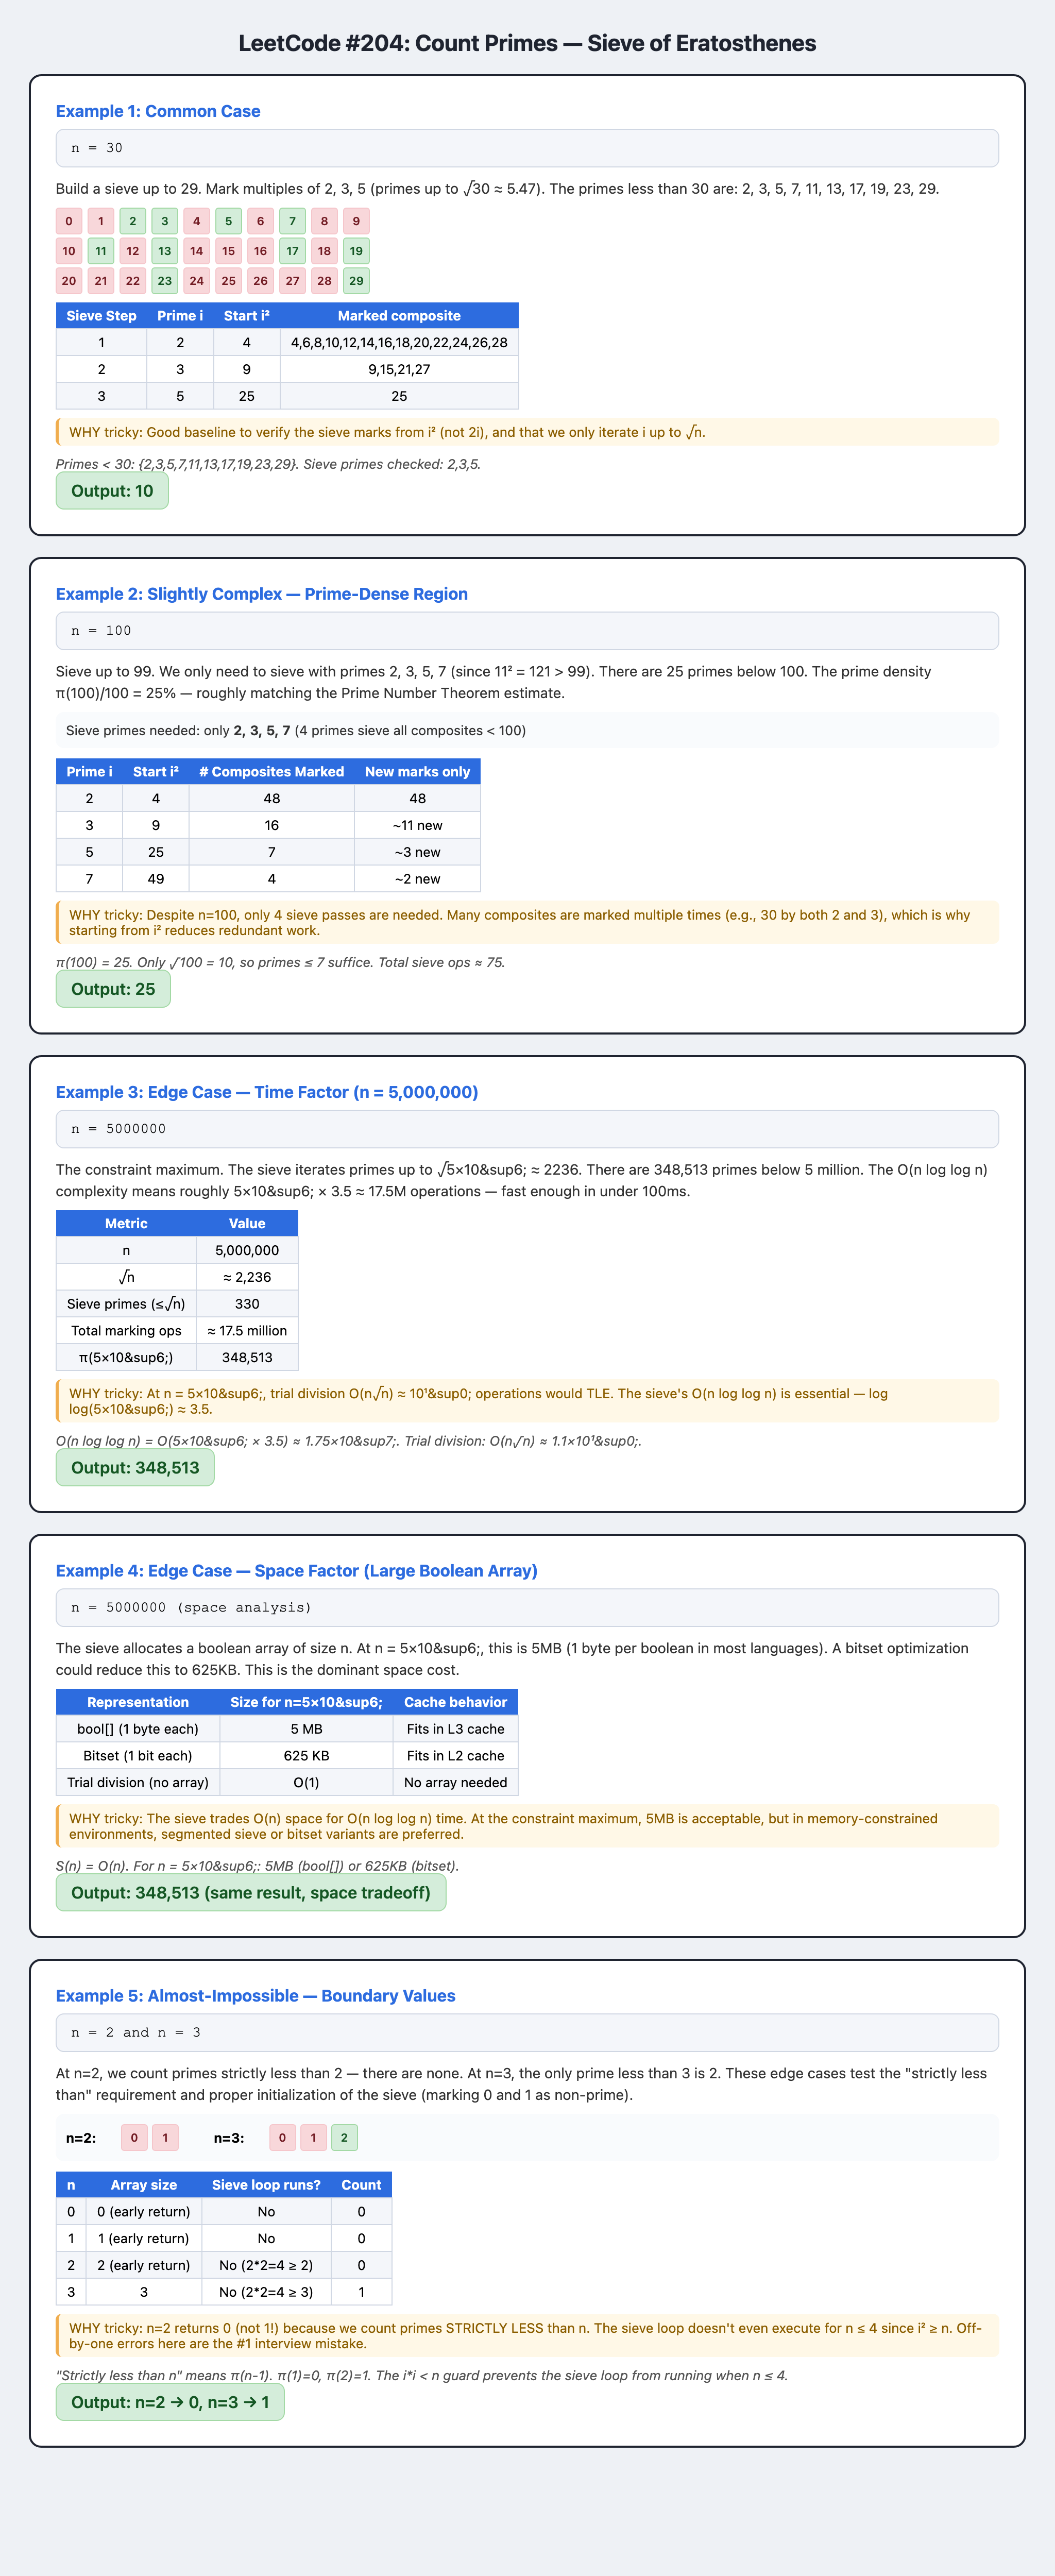